# ⚡ Week 04 — Data Science Lifecycle with an LLM

## Mission: *Can we trust the data before forecasting tomorrow's electricity demand?*

Today you are part of an analytics team working with **Estonian electricity-system data**.

Your job is **not** to train a sophisticated machine-learning model.  
Your job is to move through the complete data-science lifecycle and make defensible decisions about:

- the business problem,
- data sources,
- data quality,
- temporal patterns,
- holidays and daylight saving time,
- feature engineering,
- data leakage,
- transformations,
- baseline forecasting,
- performance metrics.

You may use an LLM, but throughout the lab follow one rule:

> **The LLM may suggest. You must verify.**

### Working cycle

**🧠 THINK → 🤖 ASK → 🧪 TEST → 📊 OBSERVE → ⚖️ DECIDE**

## Learning outcomes

By the end of this practical, you should be able to:

1. turn a vague energy-sector request into a data-science problem;
2. distinguish data usefulness from data availability;
3. audit an hourly energy dataset for structural and temporal problems;
4. use an LLM to generate hypotheses without treating those hypotheses as evidence;
5. identify daily, weekly, annual, holiday, and DST effects;
6. distinguish an outlier from a confirmed error;
7. recognise simple forms of data leakage;
8. construct meaningful time-series features;
9. explain why different error metrics can prefer different forecasts;
10. use an LLM as a reviewer rather than as an answer generator.

**Suggested duration:** 2 hours  
**Suggested mode:** pairs

# 0️⃣ Setup

The practical uses the same course data as the lecture:

- `electricity-production and consumption_2022.csv`
- `weather_2022.csv`

The loader first checks local course folders and then tries the public GitHub repository.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 130)

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    from IPython.display import display, Markdown

print("ipywidgets available:", WIDGETS_AVAILABLE)

ipywidgets available: True


In [ ]:
def load_course_csv(filename, delimiter=";", decimal="."):
    local_candidates = [
        Path("data") / filename,
        Path("data2") / filename,
        Path(filename),
        Path("..") / "data" / filename,
    ]

    local_file = next((p for p in local_candidates if p.exists()), None)

    if local_file is not None:
        print("Loaded local file:", local_file)
        return pd.read_csv(local_file, delimiter=delimiter, decimal=decimal, index_col=False)

    raw_url = (
        "https://raw.githubusercontent.com/drmatson/energy_informatics/"
        f"main/data/{filename.replace(' ', '%20')}"
    )
    print("Local file not found. Trying:", raw_url)
    return pd.read_csv(raw_url, delimiter=delimiter, decimal=decimal, index_col=False)


elering_raw = load_course_csv(
    "electricity-production and consumption_2022.csv",
    delimiter=";",
    decimal=",",
)

weather_raw = load_course_csv(
    "weather_2022.csv",
    delimiter=";",
    decimal=".",
)

print("Electricity:", elering_raw.shape)
print("Weather:", weather_raw.shape)

Local file not found. Trying: https://raw.githubusercontent.com/drmatson/energy_informatics/main/data/electricity-production%20and%20consumption_2022.csv
Local file not found. Trying: https://raw.githubusercontent.com/drmatson/energy_informatics/main/data/weather_2022.csv
Electricity: (8760, 6)
Weather: (8732, 29)


In [ ]:
def show_llm_prompt(text):
    """Display a prompt for copy/paste into the student's preferred LLM."""
    display(Markdown("### 🤖 LLM prompt"))
    display(Markdown(f"```text\n{text.strip()}\n```"))

# 1️⃣ Warm-up — Who does what?

The lecture distinguishes overlapping roles such as:

- Data Analyst
- Data Scientist
- Data Engineer
- ML Engineer

Real projects overlap, so this is **not** a strict job-description test.

For each task below, choose the role that would *most likely* take the lead.

In [ ]:
role_tasks = {
    "Build and maintain a pipeline that automatically imports hourly meter data":
        "Data Engineer",
    "Explore demand patterns and explain them to management":
        "Data Analyst",
    "Design a forecasting experiment and select useful predictors":
        "Data Scientist",
    "Deploy and monitor a trained forecasting model in production":
        "ML Engineer",
}

if WIDGETS_AVAILABLE:
    role_options = ["Data Analyst", "Data Scientist", "Data Engineer", "ML Engineer"]
    role_dropdowns = {}

    for task in role_tasks:
        print("\n" + task)
        dd = widgets.Dropdown(options=["Choose..."] + role_options)
        display(dd)
        role_dropdowns[task] = dd

    button = widgets.Button(description="Check answers")
    output = widgets.Output()

    def check_roles(_):
        with output:
            clear_output()
            for task, correct in role_tasks.items():
                chosen = role_dropdowns[task].value
                mark = "✅" if chosen == correct else "◻️"
                print(f"{mark} {task}\n   Your choice: {chosen} | Suggested lead: {correct}\n")
            print("Remember: in real teams these responsibilities often overlap.")

    button.on_click(check_roles)
    display(button, output)
else:
    display(pd.DataFrame({"Task": list(role_tasks.keys())}))
    print("ipywidgets is unavailable. Discuss the likely lead role for each task.")


Build and maintain a pipeline that automatically imports hourly meter data


Dropdown(options=('Choose...', 'Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer'), value='Choos…


Explore demand patterns and explain them to management


Dropdown(options=('Choose...', 'Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer'), value='Choos…


Design a forecasting experiment and select useful predictors


Dropdown(options=('Choose...', 'Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer'), value='Choos…


Deploy and monitor a trained forecasting model in production


Dropdown(options=('Choose...', 'Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer'), value='Choos…

Button(description='Check answers', style=ButtonStyle())

Output()

# 2️⃣ Business Understanding — Ask before you model

A manager says:

> **“We need a better electricity demand forecast.”**

This is not yet a well-defined data-science problem.

### Before using an LLM
Write at least **three questions** you would ask the manager.

### ✍️ Your answer

            1. ...  
2. ...  
3. ...

            > ...

In [ ]:
show_llm_prompt("""
You are joining an energy forecasting project.

The manager says:
"We need a better electricity demand forecast."

Before discussing models, ask 8 questions needed to turn this into a well-defined
data-science problem.

Group the questions under:
- prediction target,
- forecast horizon and timing,
- available data,
- evaluation,
- operational purpose.

Do NOT recommend machine-learning algorithms yet.
""")

### 🤖 LLM prompt

```text
You are joining an energy forecasting project.

The manager says:
"We need a better electricity demand forecast."

Before discussing models, ask 8 questions needed to turn this into a well-defined
data-science problem.

Group the questions under:
- prediction target,
- forecast horizon and timing,
- available data,
- evaluation,
- operational purpose.

Do NOT recommend machine-learning algorithms yet.
```

### Define today's working problem

For the rest of this practical, assume:

- **Target:** total electricity demand
- **Resolution:** hourly
- **Horizon:** day-ahead
- **Context:** Estonia
- **Goal:** prepare trustworthy data and a defensible evaluation workflow

# 3️⃣ Data Collection — Useful does not mean available

Before looking at the files, imagine you are constructing a day-ahead forecasting system.

Which of the following variables would you like to have?

In [ ]:
candidate_sources = [
    "Historical electricity demand",
    "Tomorrow's actual demand",
    "Calendar / weekday",
    "Public-holiday calendar",
    "Tomorrow's actual temperature",
    "Day-ahead weather forecast",
    "Historical electricity price",
    "Tomorrow's realised electricity price",
    "Day-ahead price forecast available before delivery",
    "Sunrise / sunset",
    "Wind speed",
    "Social-media activity",
]

if WIDGETS_AVAILABLE:
    source_checks = {s: widgets.Checkbox(description=s, indent=False) for s in candidate_sources}
    for cb in source_checks.values():
        display(cb)
    print("Select what you would like to use. We will discuss availability afterwards.")
else:
    display(pd.DataFrame({"Candidate source": candidate_sources}))

Checkbox(value=False, description='Historical electricity demand', indent=False)

Checkbox(value=False, description="Tomorrow's actual demand", indent=False)

Checkbox(value=False, description='Calendar / weekday', indent=False)

Checkbox(value=False, description='Public-holiday calendar', indent=False)

Checkbox(value=False, description="Tomorrow's actual temperature", indent=False)

...

Checkbox(value=False, description='Day-ahead price forecast available before delivery', indent=False)

Checkbox(value=False, description='Sunrise / sunset', indent=False)

Checkbox(value=False, description='Wind speed', indent=False)

Checkbox(value=False, description='Social-media activity', indent=False)

Select what you would like to use. We will discuss availability afterwards.


### ✍️ Your answer

Which three variables are potentially useful but problematic because they may not exist at forecast time?

> ...

# 4️⃣ First contact with the data

Inspect only a small sample first.

In [ ]:
print("ELECTRICITY DATA")
display(elering_raw.head())
print(elering_raw.dtypes)

print("\nWEATHER DATA")
display(weather_raw.head())
print(weather_raw.dtypes)

ELECTRICITY DATA


,Ajatempel (UTC),Kuupaev (Eesti aeg),Tarbimine,Tootmine,Planeeritud tarbimine,Planeeritud tootmine
0,1640988000,01.01.2022 00:00,899.4,419.5,903.1,462.4
1,1640991600,01.01.2022 01:00,892.1,431.9,935.8,469.1
2,1640995200,01.01.2022 02:00,874.3,428.1,897.6,458.6
3,1640998800,01.01.2022 03:00,860.1,435.7,878.5,471.9
4,1641002400,01.01.2022 04:00,842.7,429.2,891.1,472.2


Ajatempel (UTC)            int64
Kuupaev (Eesti aeg)       object
Tarbimine                float64
Tootmine                 float64
Planeeritud tarbimine    float64
Planeeritud tootmine     float64
dtype: object

WEATHER DATA


,Local time in Tallinn (airport),T,Po,P,Pa,U,DD,Ff,ff10,ff3,N,WW,W1,W2,Tn,Tx,Cl,Nh,H,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.12.2022 23:00,5.8,744.1,747.2,-0.7,93.0,Wind blowing from the south-southwest,3.0,NaN,NaN,100%.,"Rain shower(s), slight.",Shower(s).,Cloud covering more than 1/2 of the sky throug...,2.9,6.0,Stratus fractus or Cumulus fractus of bad weat...,100%.,200-300,NaN,NaN,35.0,4.8,0.1,3.0,NaN,NaN,NaN,NaN
1,31.12.2022 22:00,5.9,744.3,747.3,-0.5,93.0,Wind blowing from the south-west,4.0,9.0,10.0,100%.,No significant weather observed.,No significant weather observed.,No significant weather observed.,2.9,5.9,NaN,100%.,200-300,NaN,NaN,35.0,4.8,0.2,3.0,NaN,NaN,NaN,NaN
2,31.12.2022 21:00,5.8,744.4,747.4,-0.3,93.0,Wind blowing from the south-southwest,4.0,8.0,NaN,100%.,No significant weather observed.,No significant weather observed.,No significant weather observed.,2.9,5.8,NaN,100%.,100-200,NaN,NaN,35.0,4.8,0.2,3.0,NaN,NaN,NaN,NaN
3,31.12.2022 20:00,5.7,744.8,747.8,-0.5,94.0,Wind blowing from the south-west,4.0,9.0,NaN,100%.,State of sky on the whole unchanged.,Drizzle.,Cloud covering more than 1/2 of the sky throug...,2.6,5.8,Stratus nebulosus or Stratus fractus other tha...,100%.,100-200,NaN,NaN,35.0,4.8,0.5,12.0,NaN,NaN,NaN,NaN
4,31.12.2022 19:00,5.4,744.8,747.9,-0.8,96.0,Wind blowing from the south-west,4.0,8.0,NaN,100%.,No significant weather observed.,Visibility reduced.,No significant weather observed.,2.6,5.5,NaN,100%.,100-200,NaN,NaN,20.0,4.8,0.3,3.0,NaN,NaN,NaN,NaN


Local time in Tallinn (airport)     object
T                                  float64
Po                                 float64
P                                  float64
Pa                                 float64
U                                  float64
DD                                  object
Ff                                 float64
ff10                               float64
ff3                                float64
N                                   object
WW                                  object
W1                                  object
W2                                  object
Tn                                 float64
Tx                                 float64
Cl                                  object
Nh                                  object
H                                   object
Cm                                  object
Ch                                  object
VV                                 float64
Td                                 float64
RRR        

In [ ]:
print("Missing values — electricity")
display(elering_raw.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values — weather")
display(weather_raw.isna().sum().sort_values(ascending=False).head(15))

Missing values — electricity


,0
Ajatempel (UTC),0
Kuupaev (Eesti aeg),0
Tarbimine,0
Tootmine,0
Planeeritud tarbimine,0
Planeeritud tootmine,0



Missing values — weather


,0
Tg,8732
E,8697
sss,8582
E',8567
ff10,7427
Ch,6641
Cm,6612
ff3,6328
Cl,6120
Nh,2443


### LLM as a checklist generator

Send the LLM **metadata and summaries**, not the complete dataset.

In [ ]:
summary_text = f"""
Electricity dataset:
shape = {elering_raw.shape}
dtypes:
{elering_raw.dtypes.to_string()}

Weather dataset:
shape = {weather_raw.shape}
dtypes:
{weather_raw.dtypes.to_string()}

Weather missing-value counts:
{weather_raw.isna().sum().sort_values(ascending=False).head(15).to_string()}
"""

show_llm_prompt(f"""
I have two hourly energy datasets.

{summary_text}

Act as a data-quality analyst.
Create a practical audit checklist for:
- timestamps,
- duplicates,
- missing values,
- data types,
- suspicious numeric values,
- temporal regularity.

For every check, state what pandas operation could test it.
Do not claim that any specific problem exists until it has been checked.
""")

### 🤖 LLM prompt

```text
I have two hourly energy datasets.


Electricity dataset:
shape = (8760, 6)
dtypes:
Ajatempel (UTC)            int64
Kuupaev (Eesti aeg)       object
Tarbimine                float64
Tootmine                 float64
Planeeritud tarbimine    float64
Planeeritud tootmine     float64

Weather dataset:
shape = (8732, 29)
dtypes:
Local time in Tallinn (airport)     object
T                                  float64
Po                                 float64
P                                  float64
Pa                                 float64
U                                  float64
DD                                  object
Ff                                 float64
ff10                               float64
ff3                                float64
N                                   object
WW                                  object
W1                                  object
W2                                  object
Tn                                 float64
Tx                                 float64
Cl                                  object
Nh                                  object
H                                   object
Cm                                  object
Ch                                  object
VV                                 float64
Td                                 float64
RRR                                 object
tR                                 float64
E                                   object
Tg                                 float64
E'                                  object
sss                                 object

Weather missing-value counts:
Tg      8732
E       8697
sss     8582
E'      8567
ff10    7427
Ch      6641
Cm      6612
ff3     6328
Cl      6120
Nh      2443
H       2211
N        125
Pa       108
Tx        83
Tn        83


Act as a data-quality analyst.
Create a practical audit checklist for:
- timestamps,
- duplicates,
- missing values,
- data types,
- suspicious numeric values,
- temporal regularity.

For every check, state what pandas operation could test it.
Do not claim that any specific problem exists until it has been checked.
```

# 5️⃣ Data Detective 🕵️

A colleague gives you a working copy of the demand table and says:

> “Something may have happened during preprocessing.”

Find the hidden problems.

### Your task

Look for:
- exact duplicate rows,
- malformed timestamps,
- missing demand,
- implausible values,
- unusual temporal structure.

**Important:** a repeated local clock hour is not automatically an error.

In [ ]:
def make_detective_copy(df):
    x = df[["Kuupaev (Eesti aeg)", "Tarbimine"]].copy().reset_index(drop=True)

    # deterministic artificial problems
    x.loc[251, "Tarbimine"] = np.nan
    x.loc[703, "Tarbimine"] = 0
    x.loc[1211, "Tarbimine"] = 9000
    x.loc[1603, "Kuupaev (Eesti aeg)"] = "32.01.2022 12:00"

    # exact duplicate record
    x = pd.concat([x, x.iloc[[101]]], ignore_index=True)

    # shuffle so that row position does not reveal the injected cases
    return x.sample(frac=1, random_state=42).reset_index(drop=True)

detective = make_detective_copy(elering_raw)
display(detective.head())
print("Rows:", len(detective))

,Kuupaev (Eesti aeg),Tarbimine
0,14.04.2022 12:00,1192.7
1,16.04.2022 11:00,873.3
2,12.03.2022 19:00,1076.7
3,09.04.2022 21:00,1013.0
4,06.06.2022 23:00,767.5


Rows: 8761


In [ ]:
audit = detective.copy()

# TODO / CHECK 1: exact duplicate rows
duplicate_rows = audit.duplicated().sum()
print("Exact duplicated rows:", duplicate_rows)

# TODO / CHECK 2: malformed timestamps
audit["timestamp"] = pd.to_datetime(
    audit["Kuupaev (Eesti aeg)"],
    dayfirst=True,
    errors="coerce"
)
print("Invalid timestamps:", audit["timestamp"].isna().sum())

# TODO / CHECK 3: missing demand
print("Missing demand values:", audit["Tarbimine"].isna().sum())

# TODO / CHECK 4: inspect extremes
display(audit["Tarbimine"].describe())
display(audit.nsmallest(5, "Tarbimine")[["timestamp", "Tarbimine"]])
display(audit.nlargest(5, "Tarbimine")[["timestamp", "Tarbimine"]])

Exact duplicated rows: 1
Invalid timestamps: 1
Missing demand values: 1


,Tarbimine
count,8760.000000
mean,934.751655
std,198.795838
min,0.000000
25%,803.400000
50%,926.350000
75%,1061.250000
max,9000.000000


,timestamp,Tarbimine
6484,2022-01-30 07:00:00,0.0
2256,2022-06-24 04:00:00,518.0
8175,2022-07-26 04:00:00,533.3
631,2022-07-26 05:00:00,534.6
714,2022-07-22 04:00:00,534.8


,timestamp,Tarbimine
2568,2022-02-20 11:00:00,9000.0
6740,2022-01-11 10:00:00,1464.2
8121,2022-01-11 09:00:00,1454.8
1412,2022-01-11 17:00:00,1450.1
4576,2022-01-11 13:00:00,1448.3


### ✍️ Your answer


Complete this table in your own words:

| Observation | Error / anomaly / valid special case? | Action | Evidence |
|---|---|---|---|
| ... | ... | ... | ... |


    > ...

# 6️⃣ Build the analysis table

Return to the original, uncorrupted files.

We keep:
- actual demand,
- planned demand,
- Tallinn temperature.

In [ ]:
elering = elering_raw.copy()
weather = weather_raw.copy()

elering["timestamp"] = pd.to_datetime(
    elering["Kuupaev (Eesti aeg)"],
    dayfirst=True,
    errors="coerce"
)

weather["timestamp"] = pd.to_datetime(
    weather["Local time in Tallinn (airport)"],
    dayfirst=True,
    errors="coerce"
)

demand = elering[
    ["timestamp", "Tarbimine", "Planeeritud tarbimine"]
].rename(
    columns={
        "Tarbimine": "demand",
        "Planeeritud tarbimine": "planned_demand",
    }
)

temperature = weather[["timestamp", "T"]].rename(columns={"T": "temperature"})

df = (
    demand.merge(temperature, on="timestamp", how="left")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["weekday"] >= 5
df["month"] = df["timestamp"].dt.month
df["date"] = df["timestamp"].dt.date

display(df.head())
print(df.shape)

,timestamp,demand,planned_demand,temperature,hour,weekday,is_weekend,month,date
0,2022-01-01 00:00:00,899.4,903.1,-1.0,0,5,True,1,2022-01-01
1,2022-01-01 01:00:00,892.1,935.8,-0.6,1,5,True,1,2022-01-01
2,2022-01-01 02:00:00,874.3,897.6,0.0,2,5,True,1,2022-01-01
3,2022-01-01 03:00:00,860.1,878.5,-0.1,3,5,True,1,2022-01-01
4,2022-01-01 04:00:00,842.7,891.1,-0.1,4,5,True,1,2022-01-01


(8761, 9)


# 7️⃣ Exploratory Data Analysis — Hypothesis Game

First look at the full year.

**Do not ask the LLM yet.**

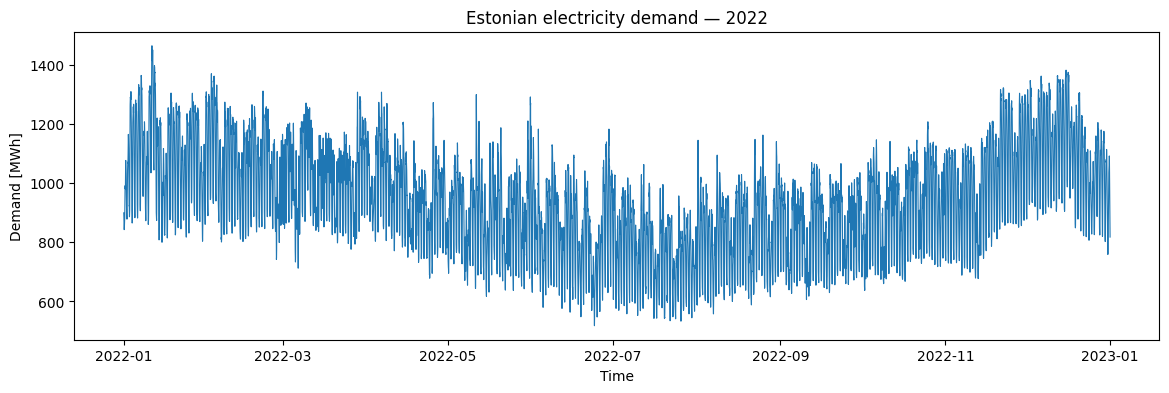

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["demand"], linewidth=0.8)
plt.title("Estonian electricity demand — 2022")
plt.xlabel("Time")
plt.ylabel("Demand [MWh]")
plt.show()

### ✍️ Your answer

Write three patterns you think may exist.

> ...

In [ ]:
show_llm_prompt("""
We have hourly total electricity demand for Estonia for one year.

Suggest 6 TESTABLE hypotheses about patterns that could exist in the series.
Include:
- intraday patterns,
- weekdays vs weekends,
- annual seasonality,
- weather,
- holidays / exceptional days.

For each hypothesis propose one plot or aggregation that would test it.

Important: phrase them as hypotheses, not as facts.
""")

### 🤖 LLM prompt

```text
We have hourly total electricity demand for Estonia for one year.

Suggest 6 TESTABLE hypotheses about patterns that could exist in the series.
Include:
- intraday patterns,
- weekdays vs weekends,
- annual seasonality,
- weather,
- holidays / exceptional days.

For each hypothesis propose one plot or aggregation that would test it.

Important: phrase them as hypotheses, not as facts.
```

## 🔬 Interactive Hypothesis Explorer

Choose a view and inspect whether the proposed pattern is visible.

In [ ]:
def plot_hypothesis(view="Hour of day"):
    plt.figure(figsize=(10, 4))

    if view == "Hour of day":
        x = df.groupby("hour")["demand"].mean()
        plt.plot(x.index, x.values, marker="o")
        plt.xticks(range(24))
        plt.xlabel("Hour")
        plt.ylabel("Mean demand [MWh]")

    elif view == "Month":
        x = df.groupby("month")["demand"].mean()
        plt.plot(x.index, x.values, marker="o")
        plt.xticks(range(1, 13))
        plt.xlabel("Month")
        plt.ylabel("Mean demand [MWh]")

    elif view == "Weekday vs weekend":
        x = (
            df.groupby(["is_weekend", "hour"])["demand"]
              .mean()
              .unstack(0)
              .rename(columns={False: "Weekday", True: "Weekend"})
        )
        plt.plot(x.index, x["Weekday"], marker="o", label="Weekday")
        plt.plot(x.index, x["Weekend"], marker="o", label="Weekend")
        plt.xticks(range(24))
        plt.xlabel("Hour")
        plt.ylabel("Mean demand [MWh]")
        plt.legend()

    elif view == "Temperature":
        sample = df.dropna(subset=["temperature", "demand"]).sample(
            n=min(2500, df.dropna(subset=["temperature", "demand"]).shape[0]),
            random_state=42
        )
        plt.scatter(sample["temperature"], sample["demand"], alpha=0.25)
        plt.xlabel("Temperature [°C]")
        plt.ylabel("Demand [MWh]")

    plt.title(view)
    plt.grid(alpha=0.3)
    plt.show()


if WIDGETS_AVAILABLE:
    widgets.interact(
        plot_hypothesis,
        view=widgets.Dropdown(
            options=["Hour of day", "Weekday vs weekend", "Month", "Temperature"],
            value="Hour of day",
            description="View:"
        )
    );
else:
    for v in ["Hour of day", "Weekday vs weekend", "Month", "Temperature"]:
        plot_hypothesis(v)

interactive(children=(Dropdown(description='View:', options=('Hour of day', 'Weekday vs weekend', 'Month', 'Te…

### ✍️ Your answer

For each view, write one evidence-based observation.

> ...

## 🤖 LLM as a critic, not as an oracle

In [ ]:
show_llm_prompt("""
Suppose I observe a negative correlation between outdoor temperature
and electricity demand in Estonia.

Give me 4 reasons why I should NOT conclude that
"temperature alone causes the observed demand changes".

Discuss:
- seasonality,
- confounding,
- time dependence,
- correlation versus causation.
""")

### 🤖 LLM prompt

```text
Suppose I observe a negative correlation between outdoor temperature
and electricity demand in Estonia.

Give me 4 reasons why I should NOT conclude that
"temperature alone causes the observed demand changes".

Discuss:
- seasonality,
- confounding,
- time dependence,
- correlation versus causation.
```

# 8️⃣ Interactive Time-Series Explorer

Zooming changes what you can see.

Use the controls to inspect:
- a whole month,
- a short interval,
- actual vs planned demand.

In [ ]:
def plot_period(month=3, days=7, show_planned=True):
    subset = df[df["month"] == month].copy()
    if subset.empty:
        return

    start = subset["timestamp"].min()
    end = start + pd.Timedelta(days=int(days))
    subset = subset[(subset["timestamp"] >= start) & (subset["timestamp"] < end)]

    plt.figure(figsize=(14, 4))
    plt.plot(subset["timestamp"], subset["demand"], label="Actual demand")
    if show_planned:
        plt.plot(subset["timestamp"], subset["planned_demand"], label="Planned demand", alpha=0.8)

    plt.title(f"Month {month}: first {days} days")
    plt.xlabel("Time")
    plt.ylabel("MWh")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


if WIDGETS_AVAILABLE:
    widgets.interact(
        plot_period,
        month=widgets.IntSlider(min=1, max=12, step=1, value=3, description="Month"),
        days=widgets.IntSlider(min=1, max=14, step=1, value=7, description="Days"),
        show_planned=widgets.Checkbox(value=True, description="Show planned")
    );
else:
    plot_period()

interactive(children=(IntSlider(value=3, description='Month', max=12, min=1), IntSlider(value=7, description='…

# 9️⃣ Holiday Detective 🏖️

Calendar patterns are not perfectly regular.

Before looking at the graph, predict what you expect around:
- Independence Day,
- Midsummer,
- Christmas.

In [ ]:
holiday_windows = {
    "Independence Day": ("2022-02-21", "2022-02-28"),
    "Midsummer": ("2022-06-20", "2022-06-27"),
    "Christmas": ("2022-12-19", "2022-12-26"),
}

reference_windows = {
    "Independence Day": ("2022-02-14", "2022-02-21"),
    "Midsummer": ("2022-06-13", "2022-06-20"),
    "Christmas": ("2022-12-12", "2022-12-19"),
}

def holiday_comparison(event="Midsummer"):
    h0, h1 = holiday_windows[event]
    r0, r1 = reference_windows[event]

    holiday = df[(df["timestamp"] >= h0) & (df["timestamp"] < h1)].copy()
    ref = df[(df["timestamp"] >= r0) & (df["timestamp"] < r1)].copy()

    holiday["hour_of_week"] = np.arange(len(holiday))
    ref["hour_of_week"] = np.arange(len(ref))

    plt.figure(figsize=(13, 4))
    plt.plot(ref["hour_of_week"], ref["demand"], label="Reference week")
    plt.plot(holiday["hour_of_week"], holiday["demand"], label=event)
    plt.xlabel("Hour of week")
    plt.ylabel("Demand [MWh]")
    plt.title(event)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


if WIDGETS_AVAILABLE:
    widgets.interact(
        holiday_comparison,
        event=widgets.Dropdown(options=list(holiday_windows), value="Midsummer")
    );
else:
    holiday_comparison("Midsummer")

interactive(children=(Dropdown(description='event', index=1, options=('Independence Day', 'Midsummer', 'Christ…

### ✍️ Your answer

Why can a model based only on `hour` and `weekday` struggle on public holidays?

> ...

# 🔟 DST Trap ⏰ — Does every day have 24 hours?

Test the assumption:

> **one local calendar day = 24 hourly observations**

In [ ]:
rows_per_day = df.groupby(df["timestamp"].dt.date).size()
unusual_day_lengths = rows_per_day[rows_per_day != 24]

display(unusual_day_lengths)

,0
timestamp,
2022-10-30,25


### ✍️ Your answer

Are these automatically data-quality errors? Explain.

> ...

In [ ]:
for day in ["2022-03-27", "2022-10-30"]:
    part = df[df["timestamp"].dt.strftime("%Y-%m-%d") == day]
    print("\n", day, "rows:", len(part))
    display(part[["timestamp", "demand"]])


 2022-03-27 rows: 24


,timestamp,demand
2040,2022-03-27 00:00:00,857.0
2041,2022-03-27 01:00:00,838.9
2042,2022-03-27 02:00:00,821.3
2043,2022-03-27 03:00:00,821.3
2044,2022-03-27 04:00:00,819.5
2045,2022-03-27 05:00:00,829.1
2046,2022-03-27 06:00:00,845.1
2047,2022-03-27 07:00:00,861.1
2048,2022-03-27 08:00:00,887.1
2049,2022-03-27 09:00:00,900.7



 2022-10-30 rows: 25


,timestamp,demand
7248,2022-10-30 00:00:00,768.0
7249,2022-10-30 01:00:00,748.9
7250,2022-10-30 02:00:00,734.1
7251,2022-10-30 03:00:00,724.2
7252,2022-10-30 04:00:00,718.8
7253,2022-10-30 04:00:00,718.8
7254,2022-10-30 05:00:00,729.9
7255,2022-10-30 06:00:00,763.2
7256,2022-10-30 07:00:00,786.3
7257,2022-10-30 08:00:00,838.2


### Discussion

What could go wrong if someone:

```python
df = df.drop_duplicates("timestamp")
```

without understanding DST?

### ✍️ Your answer

Write your explanation.

> ...

# 1️⃣1️⃣ Outlier Court ⚖️

An outlier is **not automatically an error**.

Build a robust IQR-based list of suspicious demand observations and inspect them in context.

In [ ]:
q1 = df["demand"].quantile(0.25)
q3 = df["demand"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

candidates = df[(df["demand"] < lower) | (df["demand"] > upper)].copy()

print("IQR limits:", round(lower, 2), "to", round(upper, 2))
print("Candidate rows:", len(candidates))
display(candidates[["timestamp", "demand", "planned_demand"]].head(15))

IQR limits: 416.4 to 1448.4
Candidate rows: 4


,timestamp,demand,planned_demand
249,2022-01-11 09:00:00,1454.8,1540.5
250,2022-01-11 10:00:00,1464.2,1526.4
251,2022-01-11 11:00:00,1463.6,1508.5
257,2022-01-11 17:00:00,1450.1,1521.9


In [ ]:
def inspect_candidate(row_number=0, window_hours=12):
    if len(candidates) == 0:
        print("No IQR candidates found.")
        return

    row_number = min(int(row_number), len(candidates)-1)
    row = candidates.iloc[row_number]
    t = row["timestamp"]

    part = df[
        (df["timestamp"] >= t - pd.Timedelta(hours=window_hours)) &
        (df["timestamp"] <= t + pd.Timedelta(hours=window_hours))
    ]

    plt.figure(figsize=(12, 4))
    plt.plot(part["timestamp"], part["demand"], marker="o", label="Demand")
    plt.axvline(t, linestyle="--", label="Candidate")
    plt.title(f"Candidate: {t}")
    plt.ylabel("Demand [MWh]")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


if WIDGETS_AVAILABLE and len(candidates) > 0:
    widgets.interact(
        inspect_candidate,
        row_number=widgets.IntSlider(
            min=0, max=max(0, len(candidates)-1), step=1, value=0,
            description="Candidate"
        ),
        window_hours=widgets.IntSlider(
            min=3, max=48, step=3, value=12,
            description="± hours"
        ),
    );
else:
    inspect_candidate(0)

interactive(children=(IntSlider(value=0, description='Candidate', max=3), IntSlider(value=12, description='± h…

### ✍️ Your answer

For one candidate, choose: `error`, `real event`, or `needs more information`. What evidence would you need?

> ...

# 1️⃣2️⃣ Feature Factory 🏗️

Ask the LLM for candidate predictors, then perform a **timeline audit**.

In [ ]:
show_llm_prompt("""
We are building a day-ahead hourly electricity-demand forecast for Estonia.

Suggest 12 candidate features using:
- historical demand,
- calendar information,
- weather,
- energy-market information.

For each feature state:
1. why it may help,
2. when it becomes available,
3. whether using the realised value can cause data leakage.

Do not write modelling code.
""")

### 🤖 LLM prompt

```text
We are building a day-ahead hourly electricity-demand forecast for Estonia.

Suggest 12 candidate features using:
- historical demand,
- calendar information,
- weather,
- energy-market information.

For each feature state:
1. why it may help,
2. when it becomes available,
3. whether using the realised value can cause data leakage.

Do not write modelling code.
```

## Leakage game

Classify the candidates below as **safe**, **conditionally safe**, or **leakage** for a day-ahead forecast.

In [ ]:
leakage_candidates = [
    "Demand 7 days ago",
    "Hour of delivery",
    "Day of week",
    "Public-holiday flag",
    "Actual temperature during tomorrow's delivery hour",
    "Day-ahead weather forecast available before issuance",
    "Tomorrow's actual demand",
    "Realised electricity price during tomorrow's delivery hour",
    "A price forecast available before forecast issuance",
]

if WIDGETS_AVAILABLE:
    leak_dd = {}
    for item in leakage_candidates:
        print("\n" + item)
        dd = widgets.Dropdown(
            options=["Choose...", "Safe", "Conditionally safe", "Leakage"],
            value="Choose..."
        )
        display(dd)
        leak_dd[item] = dd
else:
    display(pd.DataFrame({"Feature": leakage_candidates}))


Demand 7 days ago


Dropdown(options=('Choose...', 'Safe', 'Conditionally safe', 'Leakage'), value='Choose...')


Hour of delivery


Dropdown(options=('Choose...', 'Safe', 'Conditionally safe', 'Leakage'), value='Choose...')


Day of week


...

Dropdown(options=('Choose...', 'Safe', 'Conditionally safe', 'Leakage'), value='Choose...')


Realised electricity price during tomorrow's delivery hour


Dropdown(options=('Choose...', 'Safe', 'Conditionally safe', 'Leakage'), value='Choose...')


A price forecast available before forecast issuance


Dropdown(options=('Choose...', 'Safe', 'Conditionally safe', 'Leakage'), value='Choose...')

## Create a few meaningful features

We will create:

- `lag_24`
- `lag_168`
- cyclic hour
- cyclic weekday
- heating-degree feature

The heating-degree feature is:

\[
HDD = \max(18 - T, 0)
\]

It is only an illustrative transformation here.

In [ ]:
feat = df.copy()

feat["lag_24"] = feat["demand"].shift(24)
feat["lag_168"] = feat["demand"].shift(168)

feat["hour_sin"] = np.sin(2*np.pi*feat["hour"]/24)
feat["hour_cos"] = np.cos(2*np.pi*feat["hour"]/24)

feat["dow_sin"] = np.sin(2*np.pi*feat["weekday"]/7)
feat["dow_cos"] = np.cos(2*np.pi*feat["weekday"]/7)

feat["heating_degree"] = np.maximum(18 - feat["temperature"], 0)

display(
    feat[
        [
            "timestamp", "demand", "temperature",
            "lag_24", "lag_168",
            "hour_sin", "hour_cos",
            "heating_degree"
        ]
    ].head(175).tail(8)
)

,timestamp,demand,temperature,lag_24,lag_168,hour_sin,hour_cos,heating_degree
167,2022-01-07 23:00:00,1039.8,-8.8,1018.1,NaN,-0.258819,9.659258e-01,26.8
168,2022-01-08 00:00:00,1004.3,-8.9,955.7,899.4,0.000000,1.000000e+00,26.9
169,2022-01-08 01:00:00,982.6,-10.2,929.1,892.1,0.258819,9.659258e-01,28.2
170,2022-01-08 02:00:00,962.7,-10.4,918.8,874.3,0.500000,8.660254e-01,28.4
171,2022-01-08 03:00:00,960.8,-10.9,906.4,860.1,0.707107,7.071068e-01,28.9
172,2022-01-08 04:00:00,955.1,-10.3,908.0,842.7,0.866025,5.000000e-01,28.3
173,2022-01-08 05:00:00,963.3,-10.7,940.1,844.7,0.965926,2.588190e-01,28.7
174,2022-01-08 06:00:00,992.6,-9.9,1048.9,852.2,1.000000,6.123234e-17,27.9


### ✍️ Your answer

Why might `heating_degree` be more meaningful than raw temperature for some energy applications?

> ...

# 1️⃣3️⃣ Transformation Playground 🎛️

The lecture discusses log, square, square-root, and scaling transformations.

Explore how a transformation changes the **distribution**, not the underlying information.

In [ ]:
def transform_values(series, method):
    x = series.dropna().astype(float)

    if method == "none":
        return x
    if method == "sqrt":
        shift = max(0, -x.min())
        return np.sqrt(x + shift)
    if method == "log1p":
        shift = max(0, -x.min())
        return np.log1p(x + shift)
    if method == "square":
        return x**2
    return x


transform_sources = {
    "Demand": df["demand"],
    "Temperature": df["temperature"],
}

# Add wind speed if the expected column exists
if "Ff" in weather.columns:
    transform_sources["Wind speed"] = pd.to_numeric(weather["Ff"], errors="coerce")


def transformation_playground(variable="Demand", method="none"):
    original = transform_sources[variable].dropna().astype(float)
    transformed = transform_values(original, method)

    print("Original skewness:", round(original.skew(), 3))
    print("Transformed skewness:", round(pd.Series(transformed).skew(), 3))

    plt.figure(figsize=(8, 4))
    plt.hist(original, bins=30, alpha=0.5, label="Original")
    plt.hist(transformed, bins=30, alpha=0.5, label=method)
    plt.title(f"{variable}: {method}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.legend()
    plt.show()


if WIDGETS_AVAILABLE:
    widgets.interact(
        transformation_playground,
        variable=widgets.Dropdown(options=list(transform_sources), value="Demand"),
        method=widgets.Dropdown(
            options=["none", "sqrt", "log1p", "square"],
            value="none"
        )
    );
else:
    transformation_playground("Demand", "sqrt")

interactive(children=(Dropdown(description='variable', options=('Demand', 'Temperature', 'Wind speed'), value=…

### ✍️ Your answer

Does a more symmetric histogram automatically mean a better feature?

> ...

# 1️⃣4️⃣ Correlation Puzzle

Correlation is useful for exploration, but:
- correlation is not causation;
- highly correlated features may be redundant;
- low linear correlation does not imply no predictive relationship.

,demand,temperature,heating_degree,lag_24,lag_168,hour_sin,hour_cos,dow_sin,dow_cos
demand,1.00,-0.47,0.51,0.88,0.89,-0.32,-0.48,0.23,-0.04
temperature,-0.47,1.00,-0.98,-0.45,-0.43,-0.14,-0.12,0.02,-0.03
heating_degree,0.51,-0.98,1.00,0.49,0.45,0.13,0.11,-0.03,0.03
lag_24,0.88,-0.45,0.49,1.00,0.82,-0.32,-0.48,0.11,-0.21
lag_168,0.89,-0.43,0.45,0.82,1.00,-0.32,-0.48,0.23,-0.04
hour_sin,-0.32,-0.14,0.13,-0.32,-0.32,1.00,0.00,-0.00,0.00
hour_cos,-0.48,-0.12,0.11,-0.48,-0.48,0.00,1.00,-0.00,0.00
dow_sin,0.23,0.02,-0.03,0.11,0.23,-0.00,-0.00,1.00,0.00
dow_cos,-0.04,-0.03,0.03,-0.21,-0.04,0.00,0.00,0.00,1.00


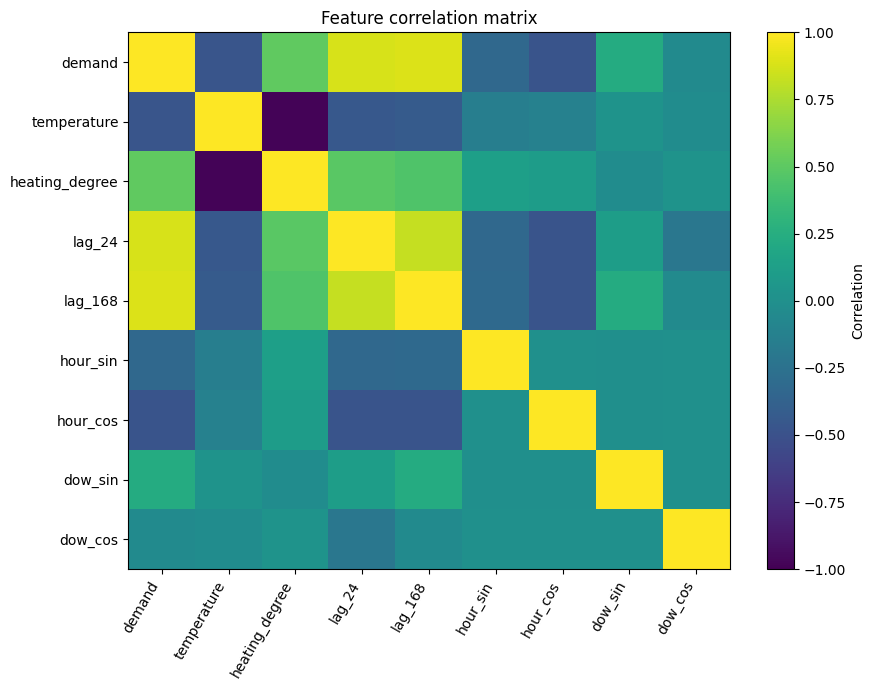

In [ ]:
corr_cols = [
    "demand", "temperature", "heating_degree",
    "lag_24", "lag_168",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
]

corr = feat[corr_cols].corr(numeric_only=True)

display(corr.round(2))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

### ✍️ Your answer

If two predictors correlate at 0.99, must one always be deleted?

> ...

# 1️⃣5️⃣ Modelling — only a baseline

Detailed modelling comes later in the course.

For now, create a very simple forecast:

> **same hour one week ago**

This is already a forecasting model — just not an ML model.

In [ ]:
baseline = feat.dropna(subset=["demand", "lag_168"]).copy()
baseline["prediction"] = baseline["lag_168"]

print("Rows available for baseline:", len(baseline))
display(baseline[["timestamp", "demand", "prediction"]].head())

Rows available for baseline: 8593


,timestamp,demand,prediction
168,2022-01-08 00:00:00,1004.3,899.4
169,2022-01-08 01:00:00,982.6,892.1
170,2022-01-08 02:00:00,962.7,874.3
171,2022-01-08 03:00:00,960.8,860.1
172,2022-01-08 04:00:00,955.1,842.7


# 1️⃣6️⃣ Metrics Playground 📏

Compare **MAE**, **RMSE**, and **MAPE**.

First compute them for the weekly baseline.

In [ ]:
def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

baseline_metrics = metrics(baseline["demand"], baseline["prediction"])
display(pd.DataFrame([baseline_metrics], index=["Weekly naive"]).round(3))

,MAE,RMSE,MAPE_%
Weekly naive,58.257,82.093,6.212


## Interactive error experiment

We will modify a 24-hour prediction artificially.

Try to answer:

> **Can you make RMSE much worse by changing only one hour?**

In [ ]:
example_day = baseline[
    (baseline["timestamp"] >= "2022-09-01") &
    (baseline["timestamp"] < "2022-09-02")
].copy()

actual_day = example_day["demand"].to_numpy()


def metric_playground(bias=0, noise=0, one_big_error=0):
    rng = np.random.default_rng(42)

    pred = actual_day.astype(float).copy()
    pred = pred + bias
    pred = pred + rng.normal(0, noise, size=len(pred))

    if len(pred) > 0:
        pred[-1] += one_big_error

    m = metrics(actual_day, pred)

    print(
        f"MAE = {m['MAE']:.2f} | "
        f"RMSE = {m['RMSE']:.2f} | "
        f"MAPE = {m['MAPE_%']:.2f}%"
    )

    plt.figure(figsize=(11, 4))
    plt.plot(range(len(actual_day)), actual_day, marker="o", label="Actual")
    plt.plot(range(len(pred)), pred, marker="o", label="Prediction")
    plt.xlabel("Hour")
    plt.ylabel("Demand [MWh]")
    plt.title("Metric playground")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


if WIDGETS_AVAILABLE:
    widgets.interact(
        metric_playground,
        bias=widgets.IntSlider(min=-150, max=150, step=10, value=0, description="Bias"),
        noise=widgets.IntSlider(min=0, max=100, step=10, value=0, description="Noise"),
        one_big_error=widgets.IntSlider(
            min=0, max=500, step=25, value=0, description="One error"
        )
    );
else:
    metric_playground(one_big_error=300)

interactive(children=(IntSlider(value=0, description='Bias', max=150, min=-150, step=10), IntSlider(value=0, d…

### ✍️ Your answer

Which metric reacts most strongly to one large miss, and why?

> ...

# 1️⃣7️⃣ Metric Battle ⚔️

Two forecasts can fail in different ways.

- Forecast A: moderate errors across many hours.
- Forecast B: very good most of the day, but one major miss.

,MAE,RMSE,MAPE_%
Forecast A,35.833,36.401,4.157
Forecast B,15.542,53.294,1.935


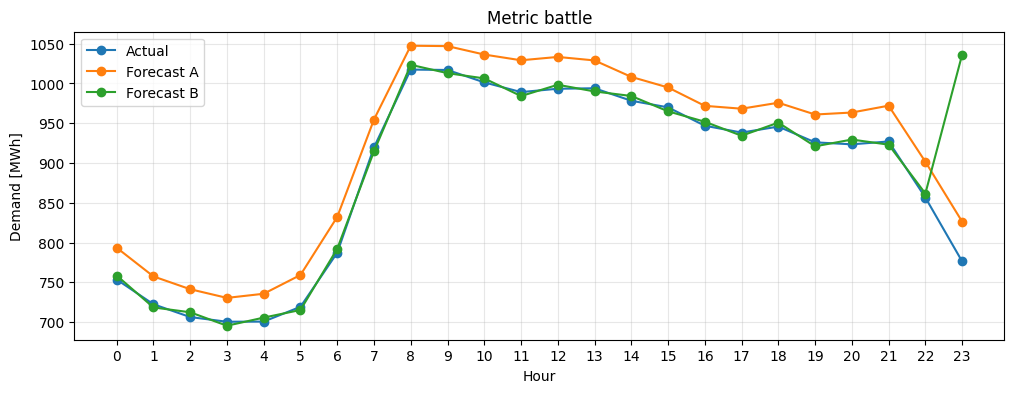

In [ ]:
y = actual_day.astype(float)

pred_A = y + np.array(
    [40, 35, 35, 30, 35, 40, 45, 35, 30, 30, 35, 40,
     40, 35, 30, 25, 25, 30, 30, 35, 40, 45, 45, 50]
)

pred_B = y + np.array(
    [5, -4, 6, -5, 5, -4, 5, -5, 6, -4, 5, -5,
     5, -4, 6, -5, 5, -4, 5, -5, 6, -4, 5, 260]
)

battle = pd.DataFrame(
    {
        "Forecast A": metrics(y, pred_A),
        "Forecast B": metrics(y, pred_B),
    }
).T

display(battle.round(3))

plt.figure(figsize=(12, 4))
plt.plot(range(24), y, marker="o", label="Actual")
plt.plot(range(24), pred_A, marker="o", label="Forecast A")
plt.plot(range(24), pred_B, marker="o", label="Forecast B")
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Demand [MWh]")
plt.title("Metric battle")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### ✍️ Your answer

Which forecast is better?

> ...

In [ ]:
show_llm_prompt(f"""
Two electricity-demand forecasts have these metrics:

{battle.round(3).to_string()}

Do NOT declare a universal winner.

Explain:
1. how the error profiles differ,
2. which metric is most sensitive to the single large miss,
3. what business information is still required before choosing a forecast.
""")

### 🤖 LLM prompt

```text
Two electricity-demand forecasts have these metrics:

               MAE    RMSE  MAPE_%
Forecast A  35.833  36.401   4.157
Forecast B  15.542  53.294   1.935

Do NOT declare a universal winner.

Explain:
1. how the error profiles differ,
2. which metric is most sensitive to the single large miss,
3. what business information is still required before choosing a forecast.
```

# 1️⃣8️⃣ LLM as Reviewer 🧑‍⚖️

At the end, reverse the relationship.

Do **not** ask the LLM to write your conclusion.

Write your conclusion first, then ask the LLM to attack it.

### Your Data Scientist Decision Card

**Business problem:**  
> ...

**Three patterns supported by the data:**  
1. ...
2. ...
3. ...

**Most dangerous data-quality issue:**  
> ...

**Three candidate features and when they become available:**  
1. ...
2. ...
3. ...

**Metric(s) you would report and why:**  
> ...

**One thing you still do not know:**  
> ...

In [ ]:
show_llm_prompt("""
Act as a skeptical reviewer of my energy-data-science decision card.

I will paste my own conclusions below.

Review them and identify:
1. one claim that needs stronger evidence,
2. one possible data-leakage risk,
3. one temporal-validation risk,
4. one additional diagnostic I should run,
5. one conclusion that is well supported.

Do not rewrite my report.
Do not invent evidence that I did not provide.

MY DECISION CARD:
[paste here]
""")

### 🤖 LLM prompt

```text
Act as a skeptical reviewer of my energy-data-science decision card.

I will paste my own conclusions below.

Review them and identify:
1. one claim that needs stronger evidence,
2. one possible data-leakage risk,
3. one temporal-validation risk,
4. one additional diagnostic I should run,
5. one conclusion that is well supported.

Do not rewrite my report.
Do not invent evidence that I did not provide.

MY DECISION CARD:
[paste here]
```

### ✍️ Your answer

Which LLM criticism did you accept, reject, or modify? Explain why.

> ...

# ✅ Practical complete

Today the LLM played several different roles:

- requirements interviewer,
- data-quality checklist generator,
- hypothesis generator,
- domain-explanation assistant,
- critical reviewer.

The core question throughout was:

> **What evidence supports this decision?**